**Data Loading**

In [2]:
#Import required libraries
import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()

#Load the dataset
df = pd.read_csv("car data.csv")

#Display the dataset
print(df.head())

Saving car data.csv to car data.csv
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


**Dataset Overview**

In [3]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


The dataset consists of 301 rows and 9 columns. It includes both numerical and categorical variables. The dataset does not contain any missing values, indicating complete records. Categorical features include Car_Name, Fuel_Type, Selling_type, and Transmission, while numerical features include Year, Selling_Price, Present_Price, Driven_kms, and Owner.

**Check Duplicate Rows**

In [4]:
df.duplicated().sum()

np.int64(2)

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.duplicated().sum()

np.int64(0)

The dataset contained 2 duplicate rows, which were removed to ensure data quality and prevent bias in model training.

**Basic Statistics**

In [7]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.566332,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [8]:
current_year = 2026
df['Car_Age'] = current_year - df['Year']

#Drop unnecessary column
df.drop(['Year'], axis=1, inplace=True)

#Select relevant features (X) and target (y)

#Target variable
y = df['Selling_Price']

#Features
X = df.drop(['Selling_Price'], axis=1)

#Handle categorical variables (Encoding)

X = pd.get_dummies(X, drop_first=True)

#Final dataset check
print("\nFinal Features Shape:", X.shape)
print("\nFeature Columns:\n", X.columns)

#Preview data
print("\nProcessed Data Sample:")
print(X.head())


Final Features Shape: (299, 105)

Feature Columns:
 Index(['Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'Car_Name_Activa 3g',
       'Car_Name_Activa 4g', 'Car_Name_Bajaj  ct 100',
       'Car_Name_Bajaj Avenger 150', 'Car_Name_Bajaj Avenger 150 street',
       'Car_Name_Bajaj Avenger 220',
       ...
       'Car_Name_swift', 'Car_Name_sx4', 'Car_Name_verna',
       'Car_Name_vitara brezza', 'Car_Name_wagon r', 'Car_Name_xcent',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual',
       'Transmission_Manual'],
      dtype='object', length=105)

Processed Data Sample:
   Present_Price  Driven_kms  Owner  Car_Age  Car_Name_Activa 3g  \
0           5.59       27000      0       12               False   
1           9.54       43000      0       13               False   
2           9.85        6900      0        9               False   
3           4.15        5200      0       15               False   
4           6.87       42450      0       12             

Relevant features such as present price, driven kilometers, fuel type, transmission type, and ownership were selected from the dataset. Additionally, a new feature ‘Car_Age’ was created from the manufacturing year to better capture the effect of vehicle age on price. Categorical variables were encoded using one-hot encoding for model compatibility.

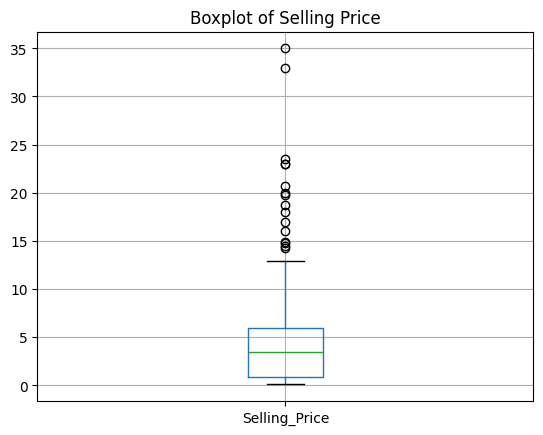

In [20]:
import matplotlib.pyplot as plt

df.boxplot(column=['Selling_Price'])
plt.title("Boxplot of Selling Price")
plt.show()

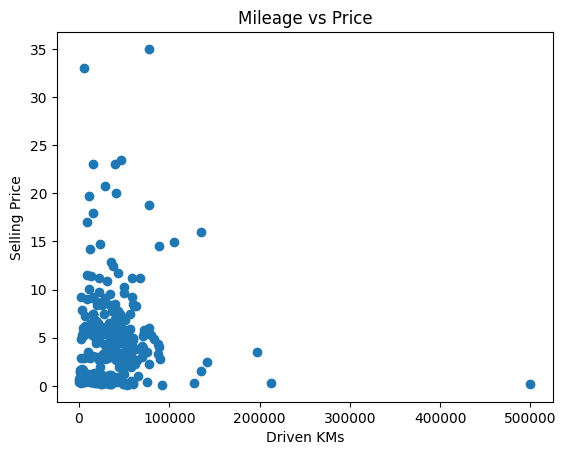

In [11]:
plt.scatter(df['Driven_kms'], df['Selling_Price'])
plt.title("Mileage vs Price")
plt.xlabel("Driven KMs")
plt.ylabel("Selling Price")
plt.show()

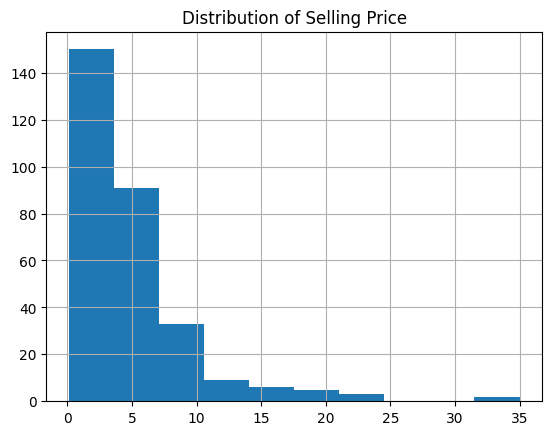

In [12]:
import matplotlib.pyplot as plt

df['Selling_Price'].hist()
plt.title("Distribution of Selling Price")
plt.show()

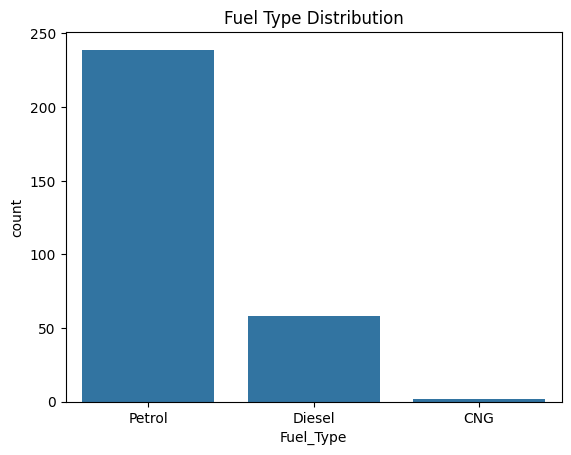

In [13]:
sns.countplot(x=df['Fuel_Type'])
plt.title("Fuel Type Distribution")
plt.show()

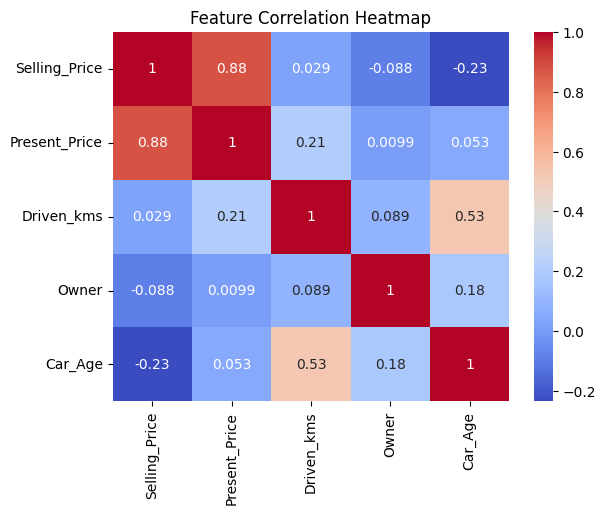

In [17]:
import seaborn as sns

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

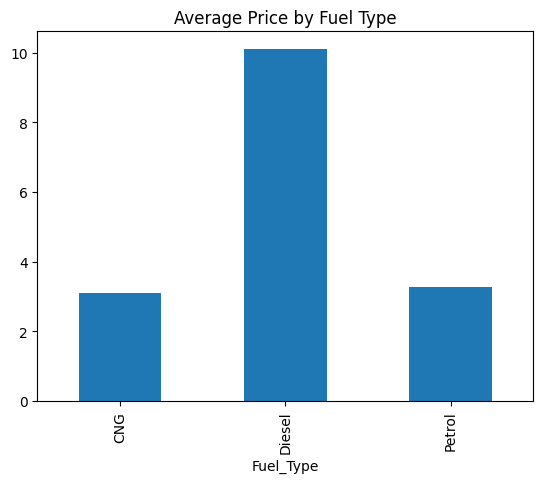

In [18]:
df.groupby('Fuel_Type')['Selling_Price'].mean().plot(kind='bar')
plt.title("Average Price by Fuel Type")
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
#Import Libraries
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

#Train Models

#Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

#Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

#Predictions

y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

#Evaluation Function

def evaluate_model(y_true, y_pred, model_name):
    print(f"\n📊 {model_name} Performance:")

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R² Score:", r2)


#Evaluate Models

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")


📊 Linear Regression Performance:
MAE : 2.622629084533153
MSE : 17.042542747688596
RMSE: 4.128261467941268
R² Score: 0.3387510435914405

📊 Random Forest Performance:
MAE : 1.348783333333334
MSE : 10.593185781000004
RMSE: 3.2547174656181763
R² Score: 0.5889854497399888


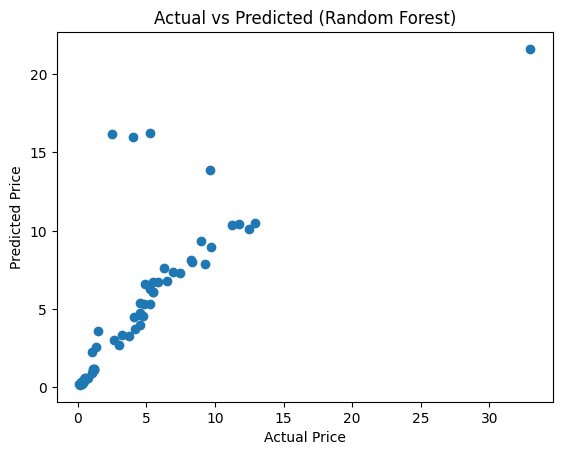

In [19]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

Two regression models were evaluated: **Linear Regression** and **Random Forest Regressor**. **Linear Regression achieved an R² score of 0.34**, indicating limited ability to capture the underlying patterns in the data. In contrast, **Random Forest achieved a higher R² score of 0.59 with lower error values (MAE: 1.34, RMSE: 3.25)**, demonstrating better predictive performance due to its ability to model non-linear relationships between features and car prices.

The results indicate that the relationship between features and car price is non-linear, making ensemble models like Random Forest more suitable than simple linear models.

Machine learning-based price prediction models are widely used in real-world applications such as used car marketplaces, where they help estimate fair vehicle prices based on features like mileage, brand, and engine power. Similar approaches are also used in real estate, insurance valuation, and electronics resale markets. These models assist businesses in making data-driven pricing decisions and improving market transparency.